# 1. Mục tiêu Thực Hiện Pipeline Dự Báo
Mục tiêu của pipeline là chuyển chuỗi thời gian thô thành ma trận đặc trưng giàu thông tin để dự báo $t+1$ ổn định và có thể đo lường được chất lượng tiền xử lý bằng các chỉ số định lượng (MAE, RMSE).

## Pipeline 4 Bước: Từ Feature Engineering Đến Mô Hình RFR
1. **Xây dựng lag features từ PACF**: xác định bậc trễ $p$ bằng PACF, sau đó tạo các đặc trưng $t-1, t-2, ..., t-p$ để mô hình học được phụ thuộc theo thời gian.
2. **Tạo rolling và time features**: bổ sung rolling statistics trên nhiều cửa sổ (ví dụ: 3, 7, 14, 30) như mean/std/min/max, đồng thời thêm đặc trưng lịch (day of week, month, day of year, weekend, chu kỳ sin-cos).
3. **Bổ sung đặc trưng từ chuỗi phân rã**: phân rã chuỗi thành trend, seasonal, residual (STL hoặc additive) và đưa các thành phần này (dạng lag) vào feature matrix.
4. **Huấn luyện mô hình RFR cho $t+1$**: dùng `RandomForestRegressor` với temporal split train/test, sau đó báo cáo MAE và RMSE trên tập test để làm bằng chứng định lượng cho hiệu quả tiền xử lý.

## Cấu hình thực nghiệm được chọn
Dựa trên phần nhận xét đã có, pipeline dưới đây dùng các cấu hình chính sau:

- **Chuỗi mục tiêu**: dùng `Confirmed` theo ngày cho **US**, tổng là **270 mẫu**, sau đó lấy sai phân để tạo `New_Cases`.
- **Khử không dừng**: chọn **sai phân bậc 1 (`d=1`)** vì notebook stationarity kết luận đây là phương pháp tối ưu.
- **PACF và lag**: PACF nhấn mạnh **lag 1** là ảnh hưởng trực tiếp mạnh nhất; code vẫn tự chọn `p` từ PACF trên chuỗi đã sai phân để bám dữ liệu thực tế.
- **Rolling statistics đa tỉ lệ**: dùng cửa sổ **[7, 30, 90]** (ngắn hạn, trung hạn, dài hạn) theo đúng tinh thần notebook rolling.
- **Phân rã chuỗi**: dùng **STL additive** với `period=7` (chu kỳ tuần) và `robust=True` để giảm ảnh hưởng outlier.
- **Bài toán dự báo**: dự báo **`t+1`** với temporal split `train_ratio=0.8`.
- **Mô hình**: `RandomForestRegressor` với `n_estimators=500`, `random_state=42`, `n_jobs=-1`.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import pacf

# Cho phép import module trong src/
for src_path in (os.path.abspath("../src"), os.path.abspath("src")):
    if os.path.isdir(src_path) and src_path not in sys.path:
        sys.path.append(src_path)

CONFIG = {
    "data_path": "../data/time_series/time-series-19-covid-combined.csv",
    "time_column": "Date",
    "entity_column": "Country/Region",
    "entity_value": "US",
    "max_pacf_lags": 40,
    "p_upper_bound": 14,
    "rolling_windows": [7, 30, 90],
    "stl_period": 7,
    "forecast_horizon": 1,
    "train_ratio": 0.8,
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_leaf": 1,
    "random_state": 42,
}

print("Cau hinh dang dung:")
for k, v in CONFIG.items():
    print(f"- {k}: {v}")

Cau hinh dang dung:
- data_path: ../data/time_series/time-series-19-covid-combined.csv
- time_column: Date
- entity_column: Country/Region
- entity_value: US
- max_pacf_lags: 40
- p_upper_bound: 14
- rolling_windows: [7, 30, 90]
- stl_period: 7
- forecast_horizon: 1
- train_ratio: 0.8
- n_estimators: 500
- max_depth: None
- min_samples_leaf: 1
- random_state: 42


## Bước 1. Chuẩn bị chuỗi mục tiêu dự báo
Ở bước này ta tạo chuỗi `New_Cases` để làm target cho bài toán dự báo `t+1`.

**Tham số quan trọng và ý nghĩa:**
- `entity_value='US'`: chọn đúng phạm vi phân tích theo các notebook ACF/PACF và rolling.
- `time_column='Date'`: đảm bảo thứ tự thời gian đúng để tránh rò rỉ dữ liệu.
- `New_Cases = diff(Confirmed)`: áp dụng kết luận `d=1` từ notebook stationarity để xử lý tính không dừng.

In [2]:
# Step 1: Load va tao chuoi New_Cases
raw = pd.read_csv(CONFIG["data_path"])
raw[CONFIG["time_column"]] = pd.to_datetime(raw[CONFIG["time_column"]], errors="coerce")
raw = raw.dropna(subset=[CONFIG["time_column"], "Confirmed"])

if CONFIG["entity_column"] in raw.columns and CONFIG["entity_value"] != "World":
    raw = raw.loc[raw[CONFIG["entity_column"]] == CONFIG["entity_value"]].copy()

daily = (
    raw.groupby(CONFIG["time_column"], as_index=False)["Confirmed"]
    .sum()
    .sort_values(CONFIG["time_column"])
    .reset_index(drop=True)
)

daily["New_Cases"] = daily["Confirmed"].diff().fillna(0).clip(lower=0)
feature_df = daily[[CONFIG["time_column"], "New_Cases"]].copy()

print(f"So dong du lieu sau gom nhom: {len(feature_df)}")
print(feature_df.head(5).to_string(index=False))

So dong du lieu sau gom nhom: 270
      Date  New_Cases
2020-01-22        0.0
2020-01-23        0.0
2020-01-24        1.0
2020-01-25        0.0
2020-01-26        3.0


## Bước 2. Chọn `p` từ PACF và tạo lag features
Ta ước lượng PACF trên chuỗi đã sai phân để chọn bậc trễ tự động, sau đó tạo các biến `lag_1...lag_p`.

**Cấu hình tham số và ý nghĩa**
- `max_pacf_lags=40`: số lag tối đa khảo sát giống notebook tương quan.
- `conf = 1.96/sqrt(n)`: ngưỡng ý nghĩa thống kê cho PACF.
- `p_upper_bound=14`: chặn trên để tránh chọn quá nhiều lag gây overfit.
- `p` chọn theo vùng significant liên tiếp từ lag 1; nếu không có thì fallback `p=1`.

In [3]:
# Step 2: PACF tren chuoi da sai phan (d=1) de chon p
diff_series = feature_df["New_Cases"].diff().dropna()
max_lag = min(CONFIG["max_pacf_lags"], max(5, len(diff_series) // 2 - 1))

pacf_values = pacf(diff_series, nlags=max_lag, method="ywm")
conf = 1.96 / np.sqrt(len(diff_series))
significant = np.abs(pacf_values[1:]) > conf

p = 0
for i, sig in enumerate(significant, start=1):
    if sig:
        p = i
    else:
        break

if p == 0:
    p = 1
p = int(min(p, CONFIG["p_upper_bound"]))

for lag in range(1, p + 1):
    feature_df[f"lag_{lag}"] = feature_df["New_Cases"].shift(lag)

pacf_table = pd.DataFrame({
    "lag": np.arange(1, len(pacf_values)),
    "pacf": pacf_values[1:],
    "is_significant": significant,
})

print(f"p duoc chon tu PACF: {p}")
print(pacf_table.head(10).to_string(index=False))

p duoc chon tu PACF: 1
 lag      pacf  is_significant
   1 -0.024997           False
   2 -0.122990            True
   3 -0.281575            True
   4 -0.270755            True
   5 -0.396970            True
   6  0.024483           False
   7  0.305360            True
   8  0.415888            True
   9  0.039876           False
  10  0.055699           False


## Bước 3. Tạo rolling statistics và time features
Bước này giúp mô hình học cả động lực ngắn hạn và bối cảnh lịch thời gian.

**Tham số quan trọng và ý nghĩa:**
- `rolling_windows=[7,30,90]`: đại diện cho tuần, tháng, và xu hướng dài hơn.
- Dùng `shift(1)` trước khi rolling: đảm bảo tại thời điểm `t` chỉ dùng thông tin quá khứ (tránh leakage).
- Time features: `dayofweek`, `month`, `weekofyear`, `is_weekend`, `sin/cos` để mô hình hóa tính chu kỳ.

In [4]:
# Step 3: Rolling features + time features
shifted = feature_df["New_Cases"].shift(1)
for w in CONFIG["rolling_windows"]:
    feature_df[f"roll_mean_{w}"] = shifted.rolling(window=w, min_periods=1).mean()
    feature_df[f"roll_std_{w}"] = shifted.rolling(window=w, min_periods=2).std()
    feature_df[f"roll_min_{w}"] = shifted.rolling(window=w, min_periods=1).min()
    feature_df[f"roll_max_{w}"] = shifted.rolling(window=w, min_periods=1).max()

dt = feature_df[CONFIG["time_column"]].dt
feature_df["year"] = dt.year
feature_df["month"] = dt.month
feature_df["day"] = dt.day
feature_df["dayofweek"] = dt.dayofweek
feature_df["dayofyear"] = dt.dayofyear
feature_df["weekofyear"] = dt.isocalendar().week.astype(int)
feature_df["quarter"] = dt.quarter
feature_df["is_month_start"] = dt.is_month_start.astype(int)
feature_df["is_month_end"] = dt.is_month_end.astype(int)
feature_df["is_weekend"] = dt.dayofweek.isin([5, 6]).astype(int)

feature_df["month_sin"] = np.sin(2 * np.pi * feature_df["month"] / 12.0)
feature_df["month_cos"] = np.cos(2 * np.pi * feature_df["month"] / 12.0)
feature_df["dow_sin"] = np.sin(2 * np.pi * feature_df["dayofweek"] / 7.0)
feature_df["dow_cos"] = np.cos(2 * np.pi * feature_df["dayofweek"] / 7.0)

print("Da tao rolling + time features.")
print(f"Tong so cot hien tai: {feature_df.shape[1]}")

Da tao rolling + time features.
Tong so cot hien tai: 29


## Bước 4. Thêm đặc trưng từ chuỗi phân rã (STL)
Ta dùng STL để tách `trend`, `seasonal`, `resid`, rồi đưa vào feature matrix dưới dạng lag 1.

**Tham số quan trọng và ý nghĩa:**
- `stl_period=7`: chu kỳ tuần cho dữ liệu ngày.
- `robust=True`: giảm ảnh hưởng của outlier.
- `shift(1)` cho các thành phần phân rã: giữ đúng nguyên tắc chỉ dùng thông tin quá khứ khi dự báo `t+1`.

In [5]:
# Step 4: Decomposition features
stl = STL(feature_df["New_Cases"], period=CONFIG["stl_period"], robust=True).fit()
feature_df["decomp_trend_lag1"] = pd.Series(stl.trend, index=feature_df.index).shift(1)
feature_df["decomp_seasonal_lag1"] = pd.Series(stl.seasonal, index=feature_df.index).shift(1)
feature_df["decomp_resid_lag1"] = pd.Series(stl.resid, index=feature_df.index).shift(1)

print("Da them decomposition features (lag1).")
print(feature_df[["decomp_trend_lag1", "decomp_seasonal_lag1", "decomp_resid_lag1"]].head(5).to_string(index=False))

Da them decomposition features (lag1).
 decomp_trend_lag1  decomp_seasonal_lag1  decomp_resid_lag1
               NaN                   NaN                NaN
          0.182596              0.232955          -0.415551
          0.283418             -0.117666          -0.165752
          0.375479              0.983882          -0.359362
          0.460351             -0.674796           0.214445


## Bước 5. Huấn luyện Random Forest Regressor và test dự báo `t+1`
Từ feature matrix đã tạo, ta chia train/test theo thời gian và huấn luyện `RandomForestRegressor`.

**Tham số quan trọng và ý nghĩa:**
- `forecast_horizon=1`: dự báo bước kế tiếp (`t+1`).
- `train_ratio=0.8`: tách 80% quá khứ để train, 20% tương lai để test.
- `n_estimators=500`: số cây; tăng độ ổn định dự báo.
- `max_depth=None`: để cây tự mở rộng (mạnh mô hình hóa phi tuyến).
- `min_samples_leaf=1`: giữ độ chi tiết của mẫu.
- `random_state=42`: tái lập kết quả.
- `n_jobs=-1`: dùng toàn bộ CPU để train nhanh hơn.

In [6]:
# Step 5: Supervised data + train/test Random Forest
h = CONFIG["forecast_horizon"]
feature_df["target_t_plus_1"] = feature_df["New_Cases"].shift(-h)
model_df = feature_df.dropna().reset_index(drop=True)

feature_cols = [
    c for c in model_df.columns
    if c not in [CONFIG["time_column"], "New_Cases", "target_t_plus_1"]
]

X = model_df[feature_cols]
y = model_df["target_t_plus_1"]

split_idx = int(len(model_df) * CONFIG["train_ratio"])
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

rf = RandomForestRegressor(
    n_estimators=CONFIG["n_estimators"],
    max_depth=CONFIG["max_depth"],
    min_samples_leaf=CONFIG["min_samples_leaf"],
    random_state=CONFIG["random_state"],
    n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

result_df = pd.DataFrame({
    CONFIG["time_column"]: model_df.loc[X_test.index, CONFIG["time_column"]].to_numpy(),
    "y_true": y_test.to_numpy(),
    "y_pred": y_pred,
})

print("=== Ket qua dinh luong tren tap test ===")
print(f"p (PACF): {p}")
print(f"So mau: {len(model_df)} | So feature: {len(feature_cols)}")
print(f"Train/Test: {len(X_train)} / {len(X_test)}")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")

=== Ket qua dinh luong tren tap test ===
p (PACF): 1
So mau: 267 | So feature: 30
Train/Test: 213 / 54
MAE  = 5301.1140
RMSE = 6492.0826


## Bước 6. Độ đo
Hai độ đo trên tập test được dùng để định lượng chất lượng của pipeline:

- **MAE**: sai số tuyệt đối trung bình của dự báo `t+1`.
- **RMSE**: nhấn mạnh sai số lớn, phản ánh độ ổn định tổng thể của pipeline.

Bạn có thể dùng trực tiếp MAE/RMSE này trong phần kết luận chất lượng tiền xử lý.

      Date  y_true    y_pred
2020-08-24 38229.0 41920.222
2020-08-25 45091.0 43488.092
2020-08-26 45871.0 42421.484
2020-08-27 46196.0 42370.292
2020-08-28 46020.0 41630.392
2020-08-29 35354.0 41268.314
2020-08-30 34512.0 39522.662
2020-08-31 42529.0 43011.872
2020-09-01 40603.0 44807.230
2020-09-02 43918.0 44796.388

Top 10 feature quan trong nhat:
          feature  importance
decomp_trend_lag1    0.258503
     roll_mean_90    0.136575
        dayofyear    0.121029
       roll_max_7    0.073082
      roll_min_90    0.061173
       weekofyear    0.060372
      roll_max_90    0.050506
      roll_max_30    0.050412
            lag_1    0.039589
      roll_mean_7    0.036414


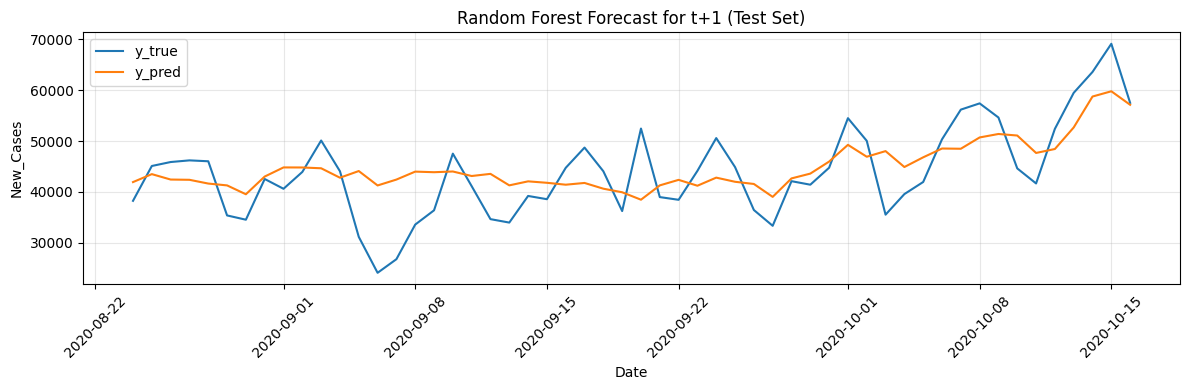

In [7]:
# Step 6: Hien thi mau du bao + do quan trong dac trung
print(result_df.head(10).to_string(index=False))

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

print("\nTop 10 feature quan trong nhat:")
print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(12, 4))
plt.plot(result_df[CONFIG["time_column"]], result_df["y_true"], label="y_true", linewidth=1.5)
plt.plot(result_df[CONFIG["time_column"]], result_df["y_pred"], label="y_pred", linewidth=1.5)
plt.title("Random Forest Forecast for t+1 (Test Set)")
plt.xlabel("Date")
plt.ylabel("New_Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Nhận xét và phân tích

### a. Nhận xét trực quan từ 2 đường y_true và y_predict

- Trên toàn tập test, hai đường có xu hướng cùng chiều ở mức khá: hệ số tương quan tổng thể xấp xỉ 0.713.
- Về cấu trúc hình dạng, mô hình bám được nhịp tăng giảm ngắn hạn, nhưng vẫn có hiện tượng làm mượt, nên các đỉnh nhọn thường bị dự báo thấp hơn thực tế và các đáy sâu thường bị dự báo cao hơn thực tế.

### b. Nhận xét các giai đoạn 2 đường có cấu trúc giống nhau

- Tháng 08/2020: độ giống khá tốt (corr khoảng 0.721, MAE tháng khoảng 3545.85).
- Tháng 10/2020: độ giống tốt nhất trong tập test (corr khoảng 0.795, MAE tháng khoảng 5524.64), đường dự báo bám khá sát pha tăng.

### c. Nhận xét giai đoạn predict kém nhất

- Tháng 09/2020: độ giống thấp (corr khoảng 0.067, MAE tháng khoảng 5649.97), mô hình có xu hướng dự báo quanh mức trung bình nhiều hơn nên chưa theo sát các dao động thực tế trong tháng.

### d. Giải thích vì sao sai số lớn

- Chuỗi New_Cases biến động mạnh và có đột biến do đặc thù báo cáo dịch tễ.
- Kích thước mẫu hữu dụng còn nhỏ (267 mẫu sau khi tạo lag, rolling và target).
- Random Forest trên dữ liệu time series thường tạo dự báo mượt hơn thực tế ở các điểm đảo chiều mạnh.
- Chưa có biến ngoại sinh (policy, mobility, vaccination, test rate), nên mô hình thiếu thông tin để giải thích các cú sốc.

Kết luận: y_true và y_predict có cấu trúc tương đối giống nhau ở cuối tháng 8 và đặc biệt là tháng 10, nhưng tháng 9 là giai đoạn hai đường lệch cấu trúc rõ nhất.

# 3. Đề xuất cải thiện khả năng dự đoán

### 1. Hướng dữ liệu

- Mở rộng dữ liệu theo thời gian: cập nhật thêm các tháng mới để tăng kích thước mẫu, giúp mô hình học tốt hơn các pha tăng giảm khác nhau.
- Bổ sung biến ngoại sinh quan trọng: policy index, mobility, testing volume, vaccination rate, holiday/event để giải thích các cú sốc mà feature nội sinh chưa bao quát.
- Nâng độ phân giải dữ liệu: thử mức Province/State (panel data) thay vì chỉ Country-level để tăng số mẫu huấn luyện.
- Xử lý outlier theo ngữ cảnh dịch tễ: dùng rolling median hoặc winsorize có kiểm soát trước khi tạo lag/rolling để giảm nhiễu từ ngày dồn báo cáo.

### 2. Hướng mô hình

- Dùng chiến lược walk-forward validation thay cho một lần split cố định để chọn mô hình ổn định hơn theo thời gian.
- So sánh nhiều mô hình: XGBoost/LightGBM/CatBoost, SARIMAX, Prophet và stacking với Random Forest hiện tại.
- Tối ưu siêu tham số có ràng buộc time series: tuning n_estimators, max_depth, min_samples_leaf, max_features bằng TimeSeriesSplit.
- Mở rộng dự báo nhiều chân trời: direct multi-horizon cho t+1, t+7, t+14 để tránh lan truyền sai số khi cần dự báo xa.

### 3. Hướng độ đo

- Giữ MAE và RMSE để so sánh với kết quả hiện tại.
- Bổ sung WAPE hoặc sMAPE để đánh giá sai số tương đối khi mức ca bệnh thay đổi mạnh theo giai đoạn.
- Bổ sung MASE để so sánh công bằng với baseline naive qua các giai đoạn khác nhau.
- Theo dõi bias và P90/P95 absolute error để kiểm soát độ lệch hệ thống và rủi ro sai số lớn ở các ngày đột biến.